### Assumptions of Linear Regression


1. **Linear relationship btwn input and output features**: The relationship between the independent variable $X$ and the dependent variable $Y$ must be linear. This can be verified using scatter plots.
2. **No Multicolinearity**: The observations are independent of each other. In time-series data, this means there is no autocorrelation.
3. **Homoscedasticity**: The residuals (errors) must have constant variance at every level of $X$. If the variance of errors differs, the model suffers from heteroscedasticity. 
    - It means when you plot the errors, it must have equal spread in the graph.
4. **Normality of Residuals**: The residuals should follow a normal distribution. This is often checked using a Q-Q plot or a Shapiro-Wilk test.
    - Bascially what it means is, if we plat the error data, it must be normally distributed.
5. **No Autocorrelation of Error**: It means if you plot all the resuduals / errors of the data, then must not be making any pattern, rather it should be equally distributed. 
6. **No Multicollinearity**: In multiple regression, independent variables should not be highly correlated with each other.
7. **No Significant Outliers**: The model is sensitive to outliers, which can disproportionately influence the slope of the regression line.




In [19]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


import warnings
warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv('data.csv')
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [21]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)
model = LinearRegression()

model.fit(X_train,y_train)
y_pred = model.predict(X_test)
residual = y_test - y_pred

### 1. Checking for linear relationship (as per assumption)

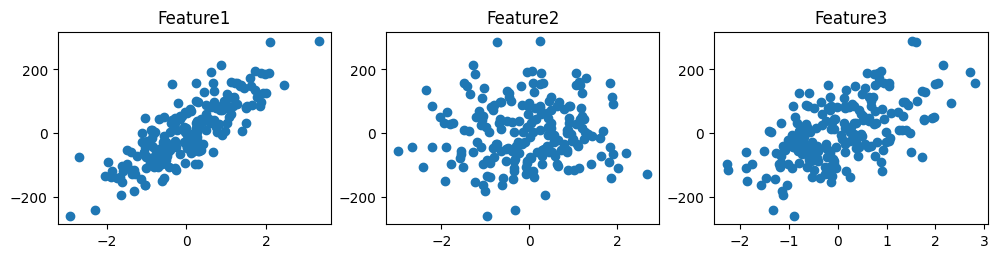

In [22]:

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

plt.show()

### 2. Checking for Multicolinearitiy

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))


pd.DataFrame({'vif' : vif}, index=df.columns[0:3]).T



,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


In [ ]:
# another way of checking for multicolinearity

X_train = pd.DataFrame(X_train, columns=['f1', 'f2', 'f3'])

X_train.corr()      # using correlation

,f1,f2,f3
f1,1.000000,-0.053983,0.082947
f2,-0.053983,1.000000,0.079830
f3,0.082947,0.079830,1.000000


### 3. Homoscedasticity

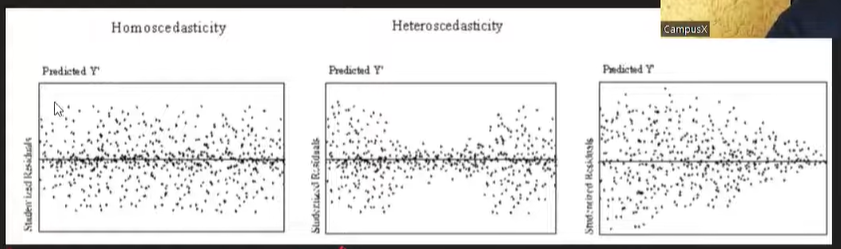

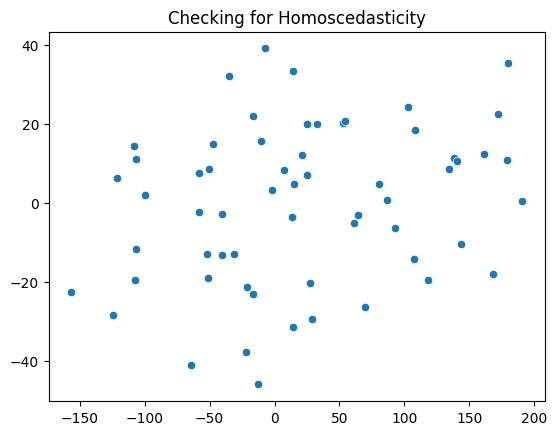

In [ ]:
sns.scatterplot(x=y_pred, y=residual)
plt.title('Checking for Homoscedasticity')

plt.show()      # as you can see below the data is not completely spread equally, but we sure can call it a Homoscedasticity

### 4. Normality of Residuals

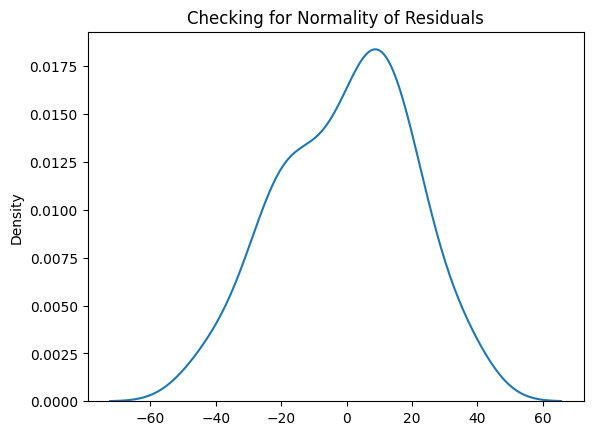

In [32]:
sns.kdeplot(residual)
plt.title('Checking for Normality of Residuals')
plt.show()      # as you can see the error is close to normally distributed

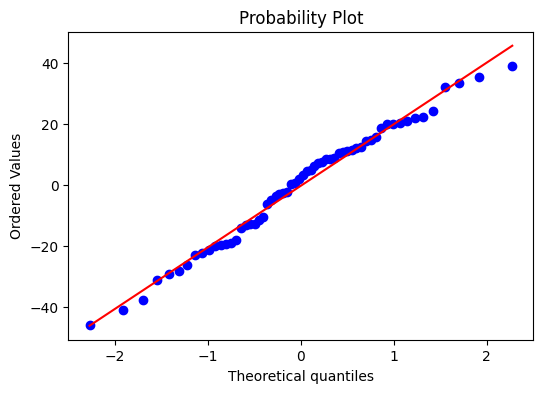

In [31]:
# another way to do the plotting

import scipy as sp

fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

### 5. No Autocorrelation of 

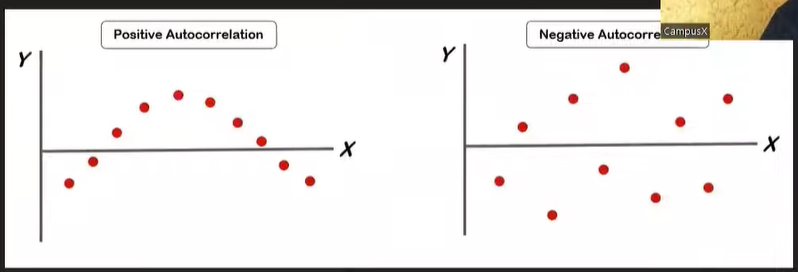

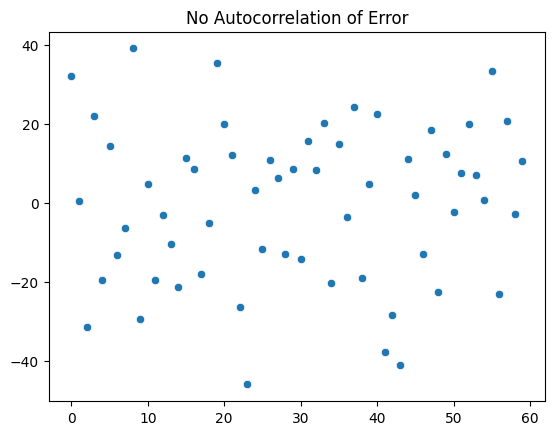

In [35]:
sns.scatterplot(residual)
plt.title('No Autocorrelation of Error')
plt.show()